**Objective:**
Predict 5-day forward returns of MSFT using technical features and evaluate whether probabilistic ensemble models produce statistically significant and tradable alpha after costs.

Horizon: 5 days

Asset: MSFT

Frequency: Daily

Cost assumption: 5 bps per trade

Positioning: Long-only



**Set Up Libaries**



In [299]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score

np.random.seed(42)

df = df.copy()

# Ensure datetime index
df.index = pd.to_datetime(df.index)
df = df.sort_index()

# Drop duplicates
df = df[~df.index.duplicated(keep="first")]

# Forward fill missing values
df = df.ffill()

df = df.dropna()

Data Preparation (using 5 day forward return)

In [300]:
# Returns
df["ret_1"] = df["Adj Close"].pct_change()
df["ret_5"] = df["Adj Close"].pct_change(5)
df["ret_10"] = df["Adj Close"].pct_change(10)

# Volatility
df["vol_20"] = df["ret_1"].rolling(20).std()

# Momentum
df["mom_10"] = df["Adj Close"] / df["Adj Close"].shift(10) - 1
df["mom_20"] = df["Adj Close"] / df["Adj Close"].shift(20) - 1

# Moving averages
df["ma_10"] = df["Adj Close"].rolling(10).mean()
df["ma_20"] = df["Adj Close"].rolling(20).mean()
df["ma_ratio"] = df["ma_10"] / df["ma_20"]

# Intraday structure
df["range"] = (df["High"] - df["Low"]) / df["Close"]
df["close_open"] = (df["Close"] - df["Open"]) / df["Open"]

# Volume signal
df["vol_z"] = (df["Volume"] - df["Volume"].rolling(20).mean()) / df["Volume"].rolling(20).std()

# Create Target
horizon = 5

df["future_return"] = df["Adj Close"].shift(-horizon) / df["Adj Close"] - 1
df["target"] = (df["future_return"] > 0).astype(int)

df = df.dropna()
print("Target distribution:")
print(df["target"].value_counts(normalize=True))

Target distribution:
target
1    0.54927
0    0.45073
Name: proportion, dtype: float64


Remove Lookahead

In [301]:
features = [
    "ret_1","ret_5","ret_10",
    "vol_20",
    "mom_10","mom_20",
    "ma_ratio",
    "range","close_open",
    "vol_z"
]

# Create feature matrix BEFORE shifting
X = df[features]
y = df["target"]

# Shift features to prevent lookahead
X = X.shift(1)

# Combine into one dataframe
data = pd.concat([X, y], axis=1).dropna()

# Drop ALL rows with NaNs (features OR target)
data = data.dropna()

# Separate again
X = data[features]
y = data["target"]

In [302]:
print("NaNs in X:", np.isnan(X).sum().sum())
print("NaNs in y:", np.isnan(y).sum())

NaNs in X: 0
NaNs in y: 0


Train / Test Split

In [303]:
train_size = int(len(df) * 0.6)
val_size   = int(len(df) * 0.2)

train = df.iloc[:train_size]
val   = df.iloc[train_size:train_size+val_size]
test  = df.iloc[train_size+val_size:]

X_train, y_train = train[features], train["target"]
X_val, y_val     = val[features], val["target"]
X_test, y_test   = test[features], test["target"]

Scale for Linear Models

In [304]:
scaler = StandardScaler()

# Preserve index
X_train_index = X_train.index
X_test_index = X_test.index

# Scale
X_train = pd.DataFrame(
    scaler.fit_transform(X_train),
    index=X_train_index,
    columns=features
)

X_test = pd.DataFrame(
    scaler.transform(X_test),
    index=X_test_index,
    columns=features
)

Train Multiple Models

In [305]:
log_model = LogisticRegression(C=0.1, max_iter=1000)
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    min_samples_leaf=10,
    random_state=42
)
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

log_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=0.05, n_estimators=200,
                           random_state=42)

Train, Predict, and Compute Sharpe Ratio

In [306]:
# Use probabilities
val_proba = (
    0.2 * log_model.predict_proba(X_val)[:,1] +
    0.4 * rf_model.predict_proba(X_val)[:,1] +
    0.4 * gb_model.predict_proba(X_val)[:,1]
)

In [307]:
# Ensemble Model
ensemble_proba = (
    0.2 * log_proba +
    0.4 * rf_proba +
    0.4 * gb_proba
)

holding_period = 5


In [308]:
thresholds = np.linspace(0.5, 0.7, 30)
cost = 0.0005

best_sharpe = -np.inf
best_thresh = None

for t in thresholds:
    signal = (val_proba > t).astype(int)
    position_change = pd.Series(signal).diff().abs().fillna(0)

    strat_ret = (
        signal * val["future_return"].values
        - position_change.values * cost
    )

    if strat_ret.std() == 0:
        continue

    sharpe = strat_ret.mean() / strat_ret.std() * np.sqrt(252/horizon)

    if sharpe > best_sharpe:
        best_sharpe = sharpe
        best_thresh = t

print("Validation Sharpe:", best_sharpe)
print("Chosen threshold:", best_thresh)

Validation Sharpe: 0.4118371499064917
Chosen threshold: 0.5413793103448276


Accuracy

In [309]:
test_proba = (
    0.2 * log_model.predict_proba(X_test)[:,1] +
    0.4 * rf_model.predict_proba(X_test)[:,1] +
    0.4 * gb_model.predict_proba(X_test)[:,1]
)

ensemble_pred = (test_proba > best_thresh).astype(int)

accuracy = accuracy_score(y_test, ensemble_pred)

print("Test Accuracy:", accuracy)

Test Accuracy: 0.5237543453070683


In [310]:
cost = 0.0005

val_proba = (
    0.2 * log_model.predict_proba(X_val)[:,1] +
    0.4 * rf_model.predict_proba(X_val)[:,1] +
    0.4 * gb_model.predict_proba(X_val)[:,1]
)

best_sharpe = -np.inf
best_thresh = None

for t in thresholds:
    signal = (val_proba > t).astype(int)
    position_change = pd.Series(signal).diff().abs().fillna(0)

    strat_ret = (
        signal * val["future_return"].values
        - position_change.values * cost
    )

    if strat_ret.std() == 0:
        continue

    sharpe = strat_ret.mean() / strat_ret.std() * np.sqrt(252/5)

    if sharpe > best_sharpe:
        best_sharpe = sharpe
        best_thresh = t

print("Validation Best Threshold:", best_thresh)
print("Validation Sharpe:", best_sharpe)

Validation Best Threshold: 0.5413793103448276
Validation Sharpe: 0.4118371499064917


In [311]:
# Create probability series aligned to X_test index
test_proba = pd.Series(
    0.2 * log_model.predict_proba(X_test)[:,1] +
    0.4 * rf_model.predict_proba(X_test)[:,1] +
    0.4 * gb_model.predict_proba(X_test)[:,1],
    index=X_test.index
)

# Align test to prediction index
test = df.loc[test_proba.index].copy()

# Create signal
test["signal"] = (test_proba > best_thresh).astype(int)

test["position_change"] = test["signal"].diff().abs().fillna(0)

final_cost = 0.0005

# --- Volatility Targeting ---
rolling_vol = test["future_return"].rolling(20).std()

target_vol = 0.15 / np.sqrt(252)   # 15% annual vol target

position_size = (target_vol / rolling_vol).clip(0, 2)

test["position_size"] = position_size

test["strategy_return"] = (
    test["signal"]
    * test["position_size"]
    * test["future_return"]
    - test["position_change"] * final_cost
)

test = test.dropna()
test["equity_curve"] = (1 + test["strategy_return"]).cumprod()

In [312]:
returns = test["strategy_return"].dropna()

sharpe = returns.mean() / returns.std() * np.sqrt(252/horizon)
annual_return = returns.mean() * (252/horizon)
volatility = returns.std() * np.sqrt(252/horizon)

equity_curve = (1 + returns).cumprod()
roll_max = equity_curve.cummax()
drawdown = equity_curve / roll_max - 1

print("Sharpe:", sharpe)
print("Annual Return:", annual_return)
print("Volatility:", volatility)
print("Max Drawdown:", drawdown.min())
print("Total Trades:", test["position_change"].sum())

Sharpe: 1.4351485065346223
Annual Return: 0.09078839976822663
Volatility: 0.06326063076736818
Max Drawdown: -0.263991047319726
Total Trades: 469.0


In [313]:
for c in [0.0005, 0.001, 0.002]:

    strat_ret = (
        test["signal"]
        * test["position_size"]   # if using vol targeting
        * test["future_return"]
        - test["position_change"] * c
    )

    sharpe = (
        strat_ret.mean() / strat_ret.std()
        * np.sqrt(252 / horizon)
    )

    print(f"Cost {c}: Sharpe {sharpe}")

Cost 0.0005: Sharpe 1.4351485065346223
Cost 0.001: Sharpe 1.3234411926602545
Cost 0.002: Sharpe 1.0991276559499146


Plot Performance

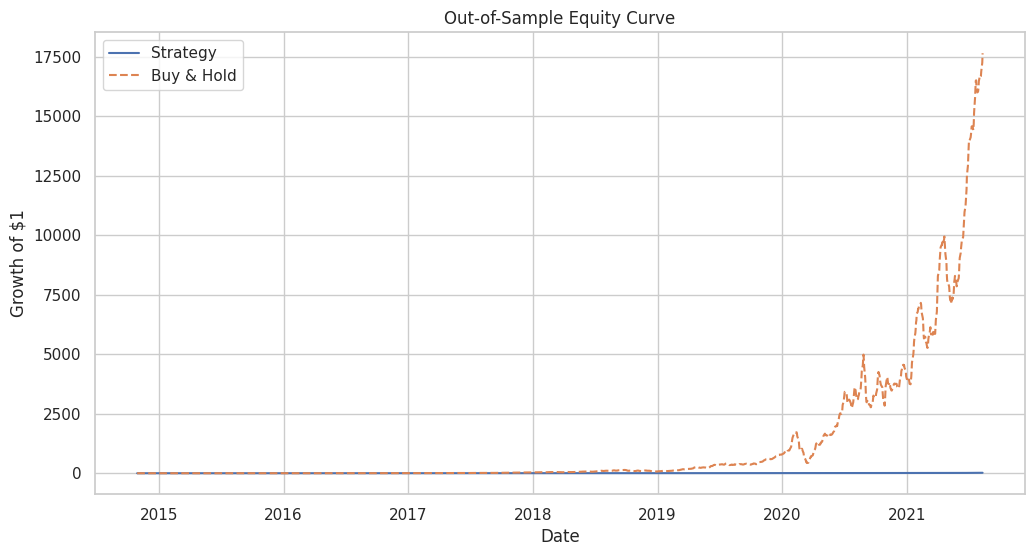

In [314]:
# Build benchmark
test["buy_hold"] = (1 + test["future_return"]).cumprod()

plt.figure(figsize=(12,6))

plt.plot(test.index, test["equity_curve"], label="Strategy")
plt.plot(test.index, test["buy_hold"], label="Buy & Hold", linestyle="--")

plt.title("Out-of-Sample Equity Curve")
plt.ylabel("Growth of $1")
plt.xlabel("Date")
plt.legend()
plt.grid(True)

plt.show()